In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
import yfinance as yf
import datetime as dt

In [2]:
coin = "BTC-USD"

start = dt.datetime(2024,1,1)
end = dt.datetime.now()

data = yf.download(coin, start, end)

data.tail()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-07-13,62239.121094,64340.882812,61769.000000,63757.171875,37650044790
2026-07-14,64956.113281,65046.132812,62207.523438,62238.585938,29841287318
2026-07-15,64712.375000,65507.593750,64442.820312,64959.808594,27029791676
2026-07-16,63789.281250,64931.855469,63701.804688,64713.296875,27232426674
2026-07-17,63198.019531,63964.578125,62503.386719,63788.523438,25535354880


In [3]:
data.isnull().sum()

Price   Ticker 
Close   BTC-USD    0
High    BTC-USD    0
Low     BTC-USD    0
Open    BTC-USD    0
Volume  BTC-USD    0
dtype: int64

In [4]:
data.reset_index()

Price,Date,Close,High,Low,Open,Volume
Ticker,,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
0,2024-01-01,44167.332031,44175.437500,42214.976562,42280.234375,18426978443
1,2024-01-02,44957.968750,45899.707031,44176.949219,44187.140625,39335274536
2,2024-01-03,42848.175781,45503.242188,40813.535156,44961.601562,46342323118
3,2024-01-04,44179.921875,44770.023438,42675.175781,42855.816406,30448091210
4,2024-01-05,44162.691406,44353.285156,42784.718750,44192.980469,32336029347
...,...,...,...,...,...,...
924,2026-07-13,62239.121094,64340.882812,61769.000000,63757.171875,37650044790
925,2026-07-14,64956.113281,65046.132812,62207.523438,62238.585938,29841287318
926,2026-07-15,64712.375000,65507.593750,64442.820312,64959.808594,27029791676


In [5]:
data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [6]:
data.to_csv("btc.csv", index = False)

In [7]:
btc = pd.read_csv("btc.csv")
btc.head()

,Close,High,Low,Open,Volume
0,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
1,44167.33203125,44175.4375,42214.9765625,42280.234375,18426978443
2,44957.96875,45899.70703125,44176.94921875,44187.140625,39335274536
3,42848.17578125,45503.2421875,40813.53515625,44961.6015625,46342323118
4,44179.921875,44770.0234375,42675.17578125,42855.81640625,30448091210


In [8]:
'''

import plotly.graph_objects as go 

fig = go.Figure(data = [go.Candlestick(x = btc['Data'],
                                        open = btc['Open'],
                                        high = btc['High'], 
                                        low = btc['Low'],
                                        close = btc['Close'])])
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

'''

"\n\nimport plotly.graph_objects as go \n\nfig = go.Figure(data = [go.Candlestick(x = btc['Data'],\n                                        open = btc['Open'],\n                                        high = btc['High'], \n                                        low = btc['Low'],\n                                        close = btc['Close'])])\nfig.update_layout(xaxis_rangeslider_visible=False)\nfig.show()\n\n"

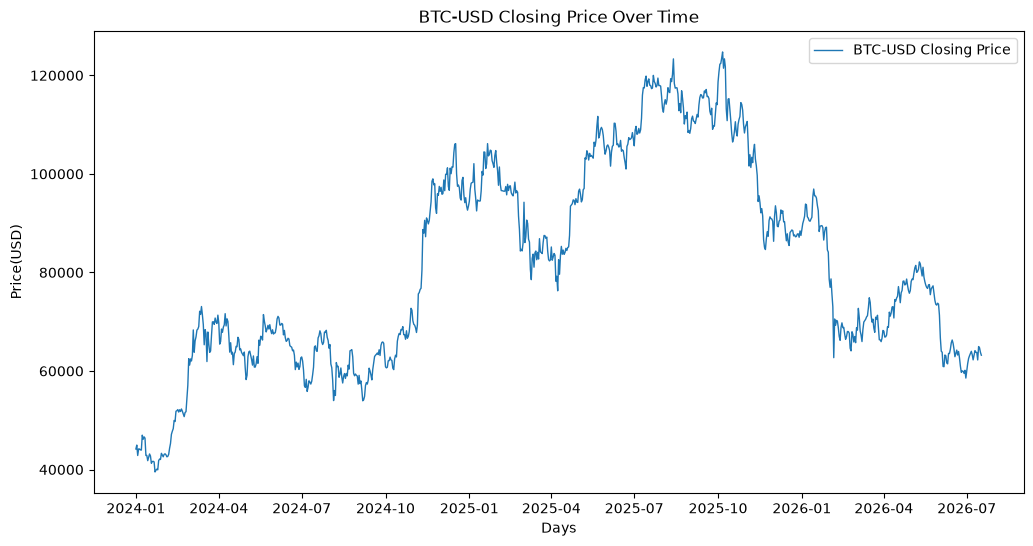

In [9]:
plt.figure(figsize = (12,6))
plt.plot(data['Close'], label = f'{coin} Closing Price', linewidth = 1)
plt.title(f'{coin} Closing Price Over Time')
plt.xlabel("Days")
plt.ylabel("Price(USD)")
plt.legend()
plt.show()

In [10]:
ma100 = data['Close'].rolling(100).mean()

print("100-day moving average:")
print(ma100.tail(10))

100-day moving average:
Ticker           BTC-USD
Date                    
2026-07-08  70879.458281
2026-07-09  70829.056641
2026-07-10  70789.542500
2026-07-11  70758.677070
2026-07-12  70726.948242
2026-07-13  70676.434297
2026-07-14  70636.176445
2026-07-15  70594.701914
2026-07-16  70513.187695
2026-07-17  70433.934297


In [11]:
ma200 = data['Close'].rolling(200).mean()

print("200-day moving average:")
print(ma200.tail(10))

200-day moving average:
Ticker           BTC-USD
Date                    
2026-07-08  74351.759121
2026-07-09  74224.616113
2026-07-10  74102.801738
2026-07-11  73984.741875
2026-07-12  73865.473164
2026-07-13  73740.495059
2026-07-14  73628.768477
2026-07-15  73513.319570
2026-07-16  73393.086797
2026-07-17  73273.386191


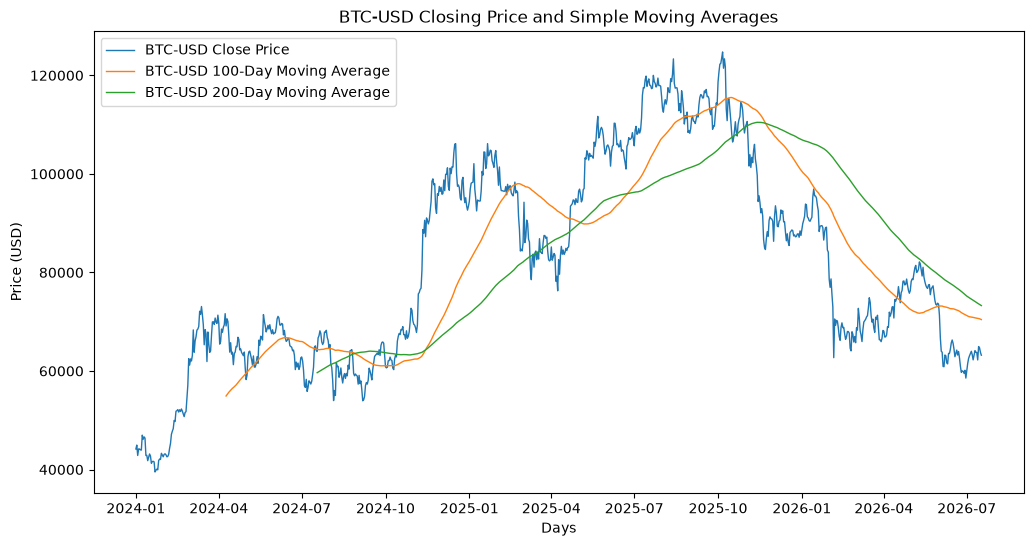

In [12]:
plt.figure(figsize=(12, 6))
plt.plot(data['Close'], label=f'{coin} Close Price', linewidth=1)
plt.plot(ma100, label=f'{coin} 100-Day Moving Average', linewidth=1)
plt.plot(ma200, label=f'{coin} 200-Day Moving Average', linewidth=1)
plt.title(f"{coin} Closing Price and Simple Moving Averages")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [13]:
data_training = pd.DataFrame(data['Close'][0:int(len(data)*0.70)])
data_test = pd.DataFrame(data['Close'][int(len(data)*0.70):])

In [14]:
scaler = MinMaxScaler(feature_range=(0,1))

In [15]:
data_training_array = scaler.fit_transform(data_training)

In [16]:
x_train = []
y_train = []

for i in range(200, data_training_array.shape[0]):
    x_train.append(data_training_array[i-200:i])
    y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [17]:
from keras.layers import Dense, Dropout, LSTM

sequential = Sequential()

sequential.add(LSTM(units = 50, activation='relu', return_sequences=True, input_shape=(x_train.shape[1], 1)))
sequential.add(Dropout(0.2))

sequential.add(LSTM(units=60, activation='relu', return_sequences=True))
sequential.add(Dropout(0.3))

sequential.add(LSTM(units=80, activation='relu', return_sequences=True))
sequential.add(Dropout(0.4))

sequential.add(LSTM(units=120, activation='relu'))
sequential.add(Dropout(0.5))

sequential.add(Dense(units=1))

c:\Users\n4tdn\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
sequential.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 200, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 200, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 200, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 200, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
sequential.compile(optimizer = 'adam', loss = 'mean_squared_error')

history = sequential.fit(x_train, y_train, epochs = 50)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 11s 303ms/step - loss: 0.2009
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - loss: 0.0363
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 287ms/step - loss: 0.0306
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 301ms/step - loss: 0.0227
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 304ms/step - loss: 0.0212
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 314ms/step - loss: 0.0173
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - loss: 0.0169
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 310ms/step - loss: 0.0187
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 315ms/step - loss: 0.0164
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step - loss: 0.0203
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 322ms/step - loss: 0.0194
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 315ms/step - loss: 0.0178
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 294ms/step - loss: 0.0160
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - loss: 0.0139
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step - l

In [20]:
past_200_days = data_training.tail(200)

In [21]:
final_df = pd.concat([past_200_days, data_test], ignore_index = True)
final_df.head()

Ticker,BTC-USD
0,86900.882812
1,87177.101562
2,84353.148438
3,82597.585938
4,82334.523438


In [22]:
test_input = scaler.fit_transform(final_df)

In [23]:
x_test = []
y_test = []

for i in range(200, test_input.shape[0]):
    x_test.append(test_input[i-200:i])
    y_test.append(test_input[i,0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [24]:
print("Shape of x_test:", x_test.shape)

Shape of x_test: (279, 200, 1)


In [25]:
y_pred = sequential.predict(x_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step


In [26]:
scale = scaler.scale_

scale_factor = 1 / scale[0]
y_pred = y_pred * scale_factor
y_test = y_test * scale_factor

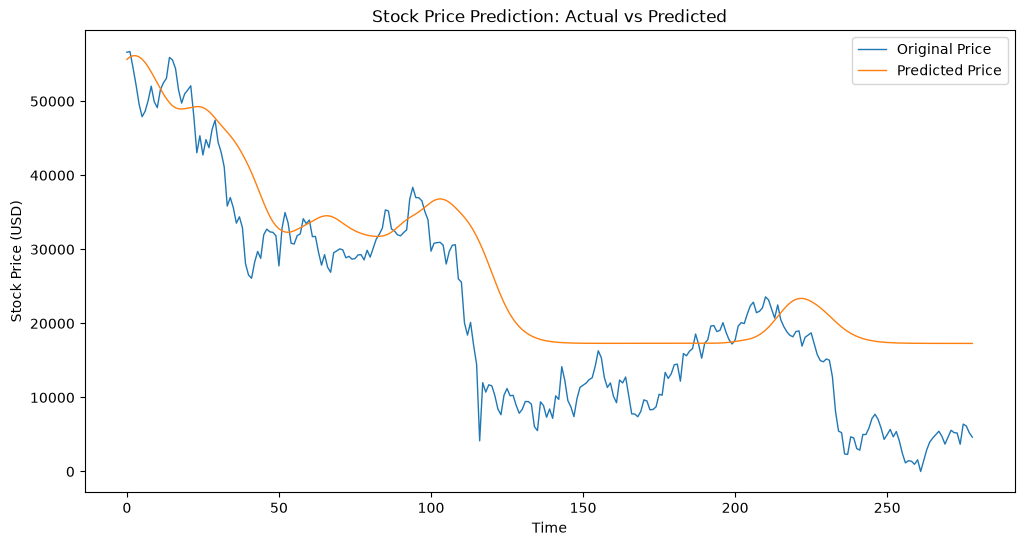

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Original Price', linewidth=1)
plt.plot(y_pred, label='Predicted Price', linewidth=1)
plt.title('Stock Price Prediction: Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.show()

In [28]:
sequential.save('btc_model.h5')